Note: This requires https://github.com/joeloskarsson/weather-model-graphs/commit/c824c23036107967898c5b3471df36445bc90e4b#diff-72daea2494478edf48e319a44c42b839b9a6175a03dd1b2fa97ca8db212a79ca to be applied to the weather-model-graphs repository to have the mesh fit to the domain and have no mesh nodes far away from the slanted domain.

In [1]:
import xarray as xr
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import weather_model_graphs as wmg
ds = xr.open_zarr("../test.zarr")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/haukeschulz/Documents/GitProjects/mllam-exps-ShCu/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/haukeschulz/Documents/GitProjects/mllam-exps-ShCu/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/haukeschulz/Documents/GitProjects/mllam-exps-ShCu/.ve

In [2]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:                                                   (cell: 11792076,
                                                               time: 10)
Coordinates:
    clat                                                      (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
    clon                                                      (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
  * time                                                      (time) datetime64[ns] 80B ...
    x                                                         (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
    y                                                         (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables: (12/19)
    clct                                                      (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    lhfl_s                                                    (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    pres_sfc                                                  (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    qv_2m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    rain_gsp_rate                                             (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    shfl_s                                                    (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    ...                                                        ...
    tot_prec                                                  (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqc_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqi_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqv_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    u_10m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    v_10m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 1.8.3rc (http://mpim...
    Conventions:          CF-1.6
    comment:              Hauke Schulz (m300408) on l40224 (Linux 4.18.0-305....
    history:              /work/mh0010/m300408/DVC-test/icon-aes/bin/icon at ...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    number_of_grid_used:  99
    references:           see MPIM/DWD publications
    source:               icon-nwp\tgit@gitlab.dkrz.de:icon/icon-nwp.git@7e23...
    title:                ICON simulation
    uuidOfHGrid:          3c7523ba-f78c-c23e-6654-012805ba3300

In [3]:
with open("domains_indices.json") as f:
    domains = json.load(f)
domain = domains["domain01"]

In [4]:
sel = ds.sel(cell=domain[::16**3])

In [5]:
sel

<xarray.Dataset> Size: 101kB
Dimensions:                                                   (cell: 128,
                                                               time: 10)
Coordinates:
    clat                                                      (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
    clon                                                      (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
  * time                                                      (time) datetime64[ns] 80B ...
    x                                                         (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
    y                                                         (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables: (12/19)
    clct                                                      (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    lhfl_s                                                    (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    pres_sfc                                                  (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    qv_2m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    rain_gsp_rate                                             (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    shfl_s                                                    (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    ...                                                        ...
    tot_prec                                                  (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqc_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqi_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqv_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    u_10m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    v_10m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 1.8.3rc (http://mpim...
    Conventions:          CF-1.6
    comment:              Hauke Schulz (m300408) on l40224 (Linux 4.18.0-305....
    history:              /work/mh0010/m300408/DVC-test/icon-aes/bin/icon at ...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    number_of_grid_used:  99
    references:           see MPIM/DWD publications
    source:               icon-nwp\tgit@gitlab.dkrz.de:icon/icon-nwp.git@7e23...
    title:                ICON simulation
    uuidOfHGrid:          3c7523ba-f78c-c23e-6654-012805ba3300

In [6]:
coords = np.rad2deg(np.stack([sel.clon.data, sel.clat.data], axis=-1)).compute()
assert coords.shape == (len(sel.clat), 2), "Shape must be (n, 2)"

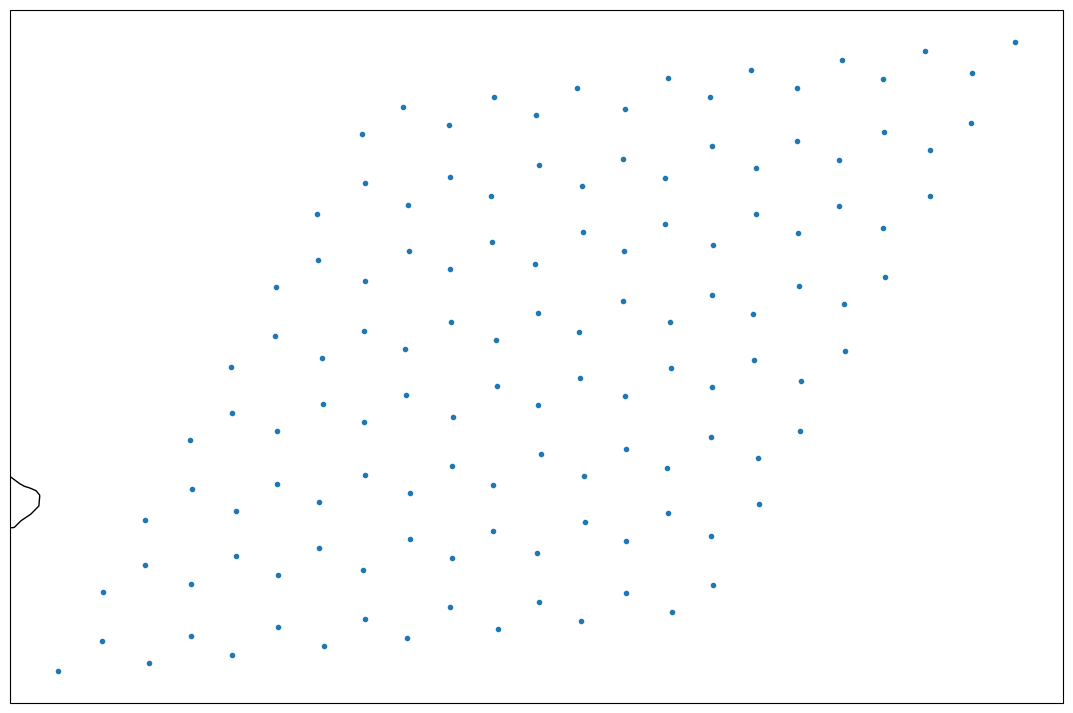

In [7]:
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.scatter(coords[:, 0], coords[:, 1], marker=".")
ax.coastlines()

2025-03-22 23:42:03.517 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:106 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.
2025-03-22 23:42:03.655 | DEBUG    | weather_model_graphs.create.mesh.mesh:create_multirange_2d_mesh_graphs:143 - mesh_levels: 1, nleaf: [6. 4.]
2025-03-22 23:42:03.673 | DEBUG    | weather_model_graphs.create.base:connect_nodes_across_graphs:424 - Longest distance in bottom mesh graph: 0.7192063859550938
2025-03-22 23:42:03.684 | DEBUG    | weather_model_graphs.create.base:connect_nodes_across_graphs:424 - Longest distance in bottom mesh graph: 0.7192063859550938


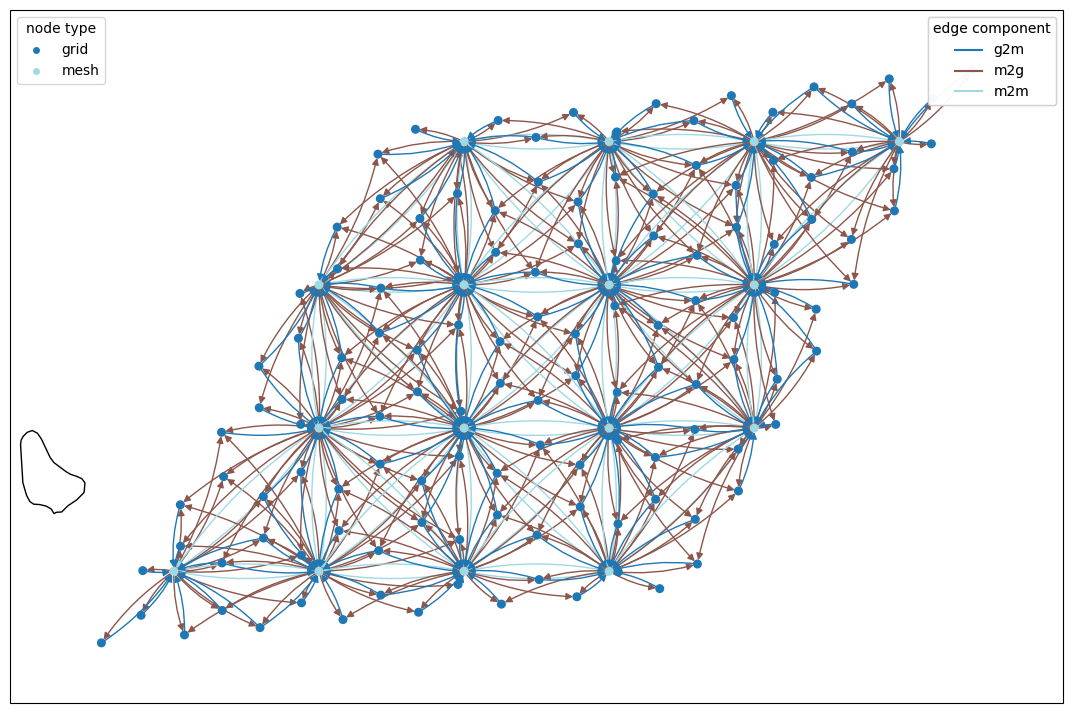

In [13]:


graph = wmg.create.archetype.create_graphcast_graph(coords, mesh_node_distance=0.5, max_num_levels=3, level_refinement_factor=3, allow_zero_degree=True)
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)
ax.coastlines()
# ax.set_extent([-60, -47, 9, 16.25])

In [14]:
# Define our projection
coords_crs = ccrs.PlateCarree()
graph_crs = ccrs.AzimuthalEquidistant(central_latitude=12.625, central_longitude=-53.5) # center of ICON 312m domain

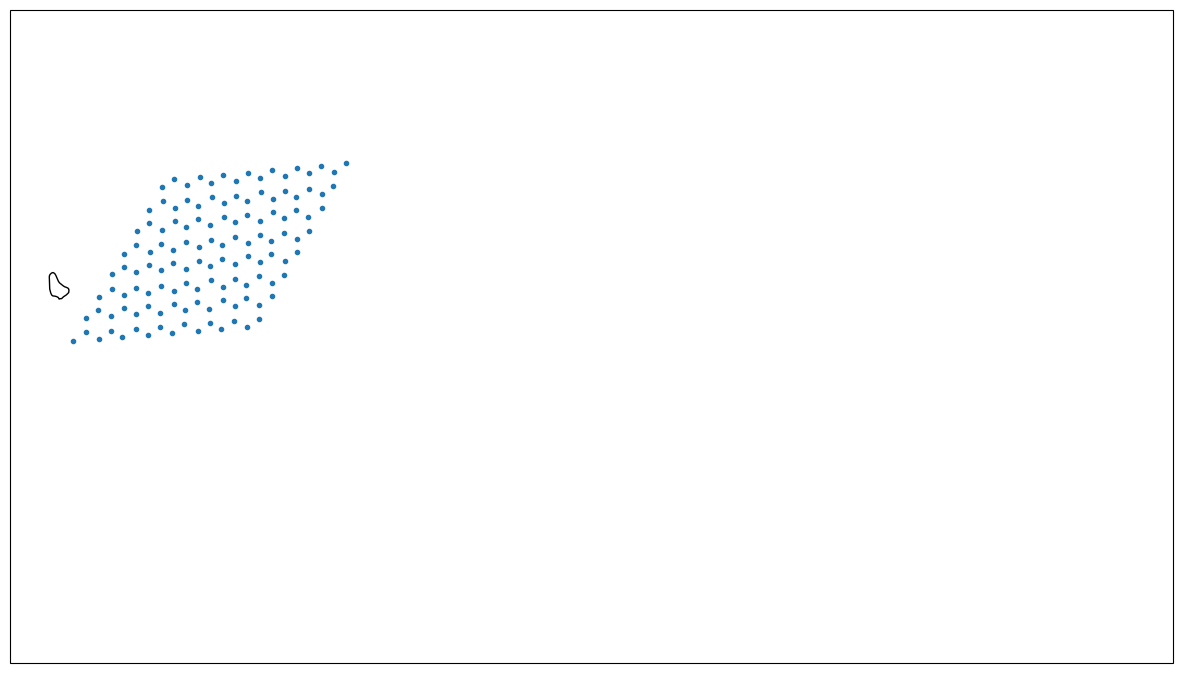

In [15]:
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": graph_crs})
ax.scatter(coords[:, 0], coords[:, 1], marker=".", transform=ccrs.PlateCarree())
_ = ax.coastlines()
ax.set_extent([-60, -47, 9, 16.25])

2025-03-22 23:42:28.653 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) to CRS(+proj=aeqd +ellps=WGS84 +lon_0=-53.5 +lat_0=12.625 +x_0=0.0 +y_0=0.0 +no_defs +type=crs) for graph creation.
2025-03-22 23:42:28.693 | DEBUG    | weather_model_graphs.create.mesh.mesh:create_multirange_2d_mesh_graphs:143 - mesh_levels: 1, nleaf: [6. 4.]
2025-03-22 23:42:28.707 | DEBUG    | weather_model_graphs.create.base:connect_nodes_across_graphs:424 - Longest distance in bottom mesh graph: 78186.72769248532
2025-03-22 23:42:28.723 | DEBUG    | weather_model_graphs.create.base:connect_nodes_across_graphs:424 - Longest distance in bottom mesh graph: 78186.72769248532


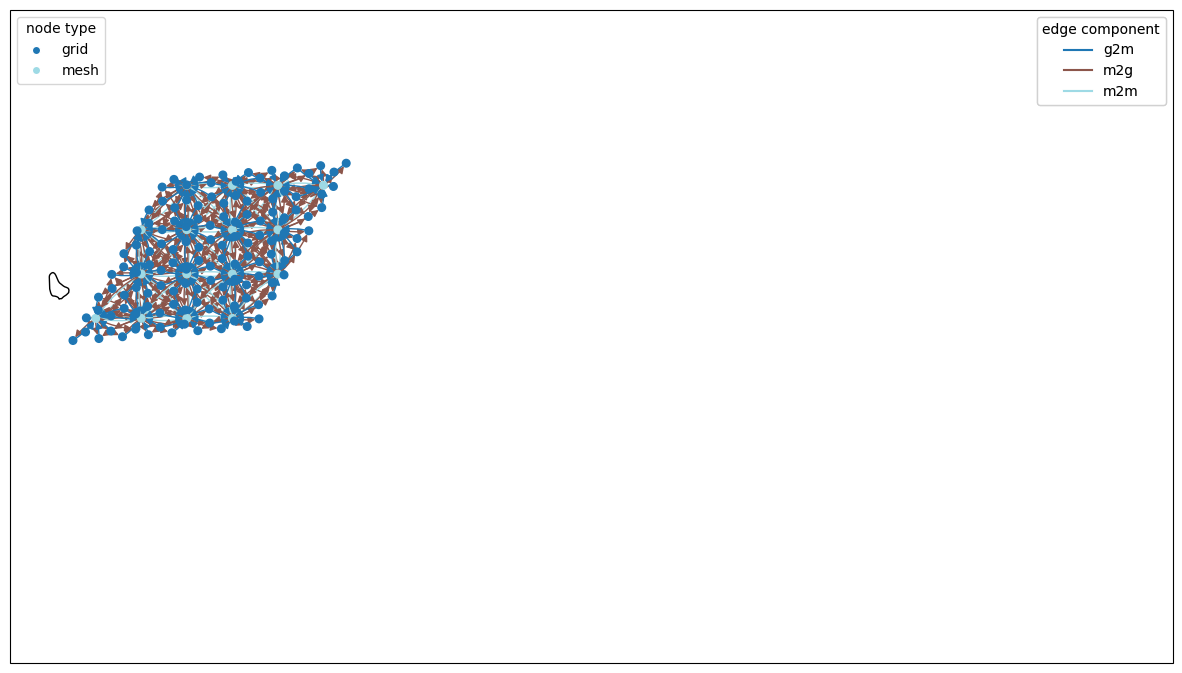

In [17]:
mesh_distance = (
    50000
)  # Large euclidean distance in projection coordinates between mesh nodes
graph = wmg.create.archetype.create_graphcast_graph(
    coords, mesh_node_distance=mesh_distance, coords_crs=coords_crs, graph_crs=graph_crs, allow_zero_degree=True
)  # Note that we here specify the projection argument
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": graph_crs})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)
_ = ax.coastlines()
ax.set_extent([-60, -47, 9, 16.25])

In [18]:
graph_components = wmg.split_graph_by_edge_attribute(graph=graph, attr='component')

In [ ]:
for component, graph in graph_components.items():
    wmg.save.to_pyg(graph=graph, name=component, output_directory="../data/graph/graphcast/")

2025-03-22 23:43:13.835 | INFO     | weather_model_graphs.save:to_pyg:150 - Saved edge index to ../data/graph/graphcast/m2g_edge_index.pt and features ['len', 'vdiff'] to ../data/graph/graphcast/m2g_features.pt.
2025-03-22 23:43:13.837 | INFO     | weather_model_graphs.save:to_pyg:157 - Saved node features ['pos'] to ../data/graph/graphcast/m2g_node_features.pt.
2025-03-22 23:43:13.844 | INFO     | weather_model_graphs.save:to_pyg:150 - Saved edge index to ../data/graph/graphcast/m2m_edge_index.pt and features ['len', 'vdiff'] to ../data/graph/graphcast/m2m_features.pt.
2025-03-22 23:43:13.845 | INFO     | weather_model_graphs.save:to_pyg:157 - Saved node features ['pos'] to ../data/graph/graphcast/m2m_node_features.pt.
2025-03-22 23:43:13.856 | INFO     | weather_model_graphs.save:to_pyg:150 - Saved edge index to ../data/graph/graphcast/g2m_edge_index.pt and features ['len', 'vdiff'] to ../data/graph/graphcast/g2m_features.pt.
2025-03-22 23:43:13.864 | INFO     | weather_model_graphs.

In [22]:
import torch
from torch_geometric.utils.convert import from_networkx

In [23]:
mesh_pos = from_networkx(graph_components['m2m']).pos.to(torch.float32)
torch.save(mesh_pos, "../data/graph/graphcast/mesh_features.pt")

In [24]:
mesh_pos

tensor([[-609641.1875,   31111.1543],
        [-553610.4375,   31111.1543],
        [-553610.4375,   85642.9766],
        [-553610.4375,  140174.7969],
        [-497579.6875,   31111.1543],
        [-497579.6875,   85642.9766],
        [-497579.6875,  140174.7969],
        [-497579.6875,  194706.6250],
        [-441548.9375,   31111.1543],
        [-441548.9375,   85642.9766],
        [-441548.9375,  140174.7969],
        [-441548.9375,  194706.6250],
        [-385518.1875,   85642.9766],
        [-385518.1875,  140174.7969],
        [-385518.1875,  194706.6250],
        [-329487.4375,  194706.6250]])